In [23]:
import warnings
warnings.filterwarnings("ignore")

In [24]:
import numpy as np
import chemcoord as cc
import pandas as pd
import matplotlib.pyplot as plt

from ase.io.trajectory import Trajectory
from flonacomldft.internal_coordinates import Coordinates_mapping
from flonacomldft.utils.silver_isomers_utils import (
    get_molecule_isomer_minima,
    get_construction_table
)

In [25]:
# Define the working directory
working_dir = "/home/amolina/ab-flowMC/ag8"
molecular_dynamics_dir = working_dir + "/1-molecular-dynamics"

# 1. Molecular dynamics trajectories

In [26]:
# Load the trajectories
ag8_trajs = {'0': Trajectory(
    molecular_dynamics_dir + "/molecular_dynamics_ag8_0_20240902035647.traj"
    ),
             '1': Trajectory(
    molecular_dynamics_dir + "/molecular_dynamics_ag8_1_20240902065506.traj"
    )}

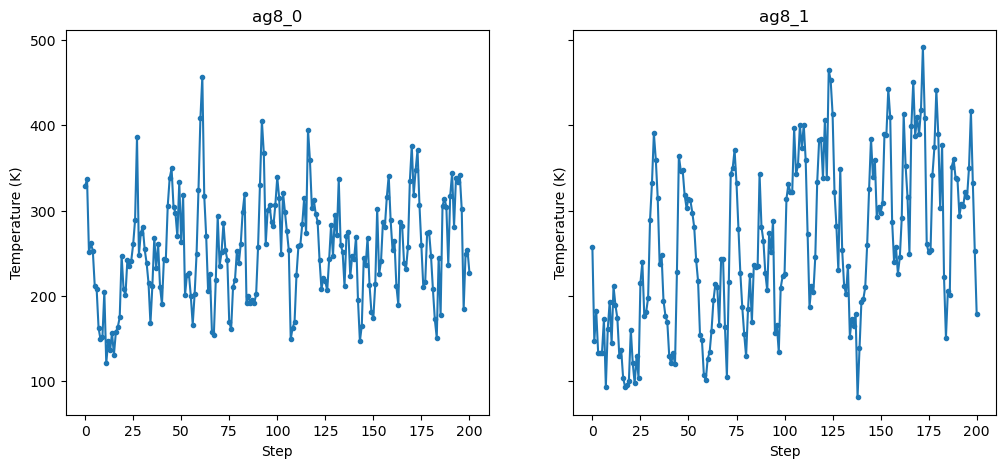

In [27]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

for i, ag8 in ag8_trajs.items():
    temperature = [atoms.get_temperature() for atoms in ag8]
    axs[int(i)].plot(temperature, '.-')
    axs[int(i)].set_xlabel('Step')
    axs[int(i)].set_ylabel('Temperature (K)')
    axs[int(i)].set_title(f'ag8_{i}')

# 2. Internal coordinates

In [28]:
cartesian = cc.Cartesian.from_ase_atoms(get_molecule_isomer_minima('FD-TPSS', 'ag8', 0))
zmat = cartesian.get_zmat()
construction_table = cartesian.get_construction_table()

print("ZMAT: Internal coordinates for isomer 0 of ag8")
zmat

ZMAT: Internal coordinates for isomer 0 of ag8


,atom,b,bond,a,angle,d,dihedral
6,Ag,$\vec{0}$,13.446089,$\vec{e_z}$,55.647465,$\vec{e_x}$,45.201584
0,Ag,6,2.793928,$\vec{e_z}$,35.249279,$\vec{e_x}$,52.827586
1,Ag,0,2.743090,6,59.293732,$\vec{e_x}$,-88.082961
2,Ag,0,2.742639,1,112.623159,6,27.355776
4,Ag,2,2.737163,0,61.728378,1,-98.553623
5,Ag,4,2.737969,2,112.104411,0,98.635043
7,Ag,5,2.738895,4,61.644410,2,-99.345051
3,Ag,7,2.737317,5,112.029030,4,-27.412233


In [29]:
#coord_maps = Coordinates_mapping(
#                                 calculator_label='LCAO',
#                                 chemical_formula='Ag6',
#                                 etype='dft')

In [30]:
print("Construction table: Using internal coordinates for isomer 0 of ag8 as reference")
construction_table

Construction table: Using internal coordinates for isomer 0 of ag8 as reference


,b,a,d
6,origin,e_z,e_x
0,6,e_z,e_x
1,0,6,e_x
2,0,1,6
4,2,0,1
5,4,2,0
7,5,4,2
3,7,5,4


In [31]:
print("Construction table save in utils.silver_isomers_utils for ag8")
get_construction_table('ag8')

Construction table save in utils.silver_isomers_utils for ag8


,b,a,d
6,origin,e_z,e_x
0,6,e_z,e_x
1,0,6,e_x
2,0,1,6
4,2,0,1
5,4,2,0
7,5,4,2
3,7,5,4


In [32]:
# Coordinates mapping object for ag8

construction_table = get_construction_table('ag8')
coord_maps = Coordinates_mapping(construction_table=construction_table,
                                 calculator_label='FD-TPSS',
                                 chemical_formula='Ag8',
                                 etype='dft')

In [33]:
zmat = coord_maps.zmat_minima[0]
molecule = coord_maps.build_molecule_from_zmat(zmat)
isomer_minima = get_molecule_isomer_minima('FD-TPSS', 'Ag8', '0')

sum_reconstruction_error = (isomer_minima.get_all_distances() - molecule.get_all_distances()).mean()

print(f"Sum of reconstruction error: {sum_reconstruction_error:.2e} Å")

Sum of reconstruction error: -5.06e-08 Å


## 2.a Internal coordinates for MD trajectories

In [34]:
database_dir = working_dir + "/database" 

In [35]:
x_interns = pd.read_csv(database_dir + "/database_ag8_0_20240910204355_zmat.csv")
x_interns

,b-0-6,b-1-0,b-2-0,b-4-2,b-5-4,b-7-5,b-3-7,a-1-0-6,a-2-0-1,a-4-2-0,...,d-2-0-1-6,d-4-2-0-1,d-5-4-2-0,d-7-5-4-2,d-3-7-5-4,potential_energy,isomer,logdetjac,C,R
0,2.878518,2.757524,2.757998,2.758848,2.757840,2.759492,2.758936,1.021975,1.942044,1.096950,...,0.466109,-1.717301,1.714999,-1.714589,-0.464793,-65.587512,0.0,13.718107,18.452002,2.333412
1,2.873867,2.757954,2.753396,2.762849,2.762239,2.762162,2.757482,1.011996,1.946276,1.096132,...,0.460809,-1.700334,1.715868,-1.722708,-0.471982,-65.584692,0.0,13.700082,18.435290,2.334930
2,2.869551,2.758422,2.753146,2.770311,2.763255,2.765115,2.753860,1.003715,1.947975,1.094209,...,0.457322,-1.685647,1.718095,-1.731860,-0.477060,-65.579389,0.0,13.686841,18.441681,2.335940
3,2.867806,2.760584,2.753380,2.780907,2.761944,2.761679,2.753394,0.996197,1.949605,1.091848,...,0.453982,-1.670987,1.721330,-1.741464,-0.481384,-65.570637,0.0,13.676898,18.442904,2.337132
4,2.863862,2.760512,2.757543,2.789117,2.761091,2.751348,2.753603,0.989905,1.948860,1.088670,...,0.451020,-1.658913,1.726130,-1.753600,-0.484655,-65.562526,0.0,13.662489,18.489732,2.337110
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
196,2.777661,2.889244,2.904893,2.799118,2.782841,2.751149,2.990888,0.984426,1.857777,1.005096,...,0.455899,-1.695441,1.788761,-1.839526,-0.375713,-65.452292,0.0,14.053494,18.967612,2.335001
197,2.785154,2.905681,2.901596,2.793239,2.787357,2.744780,3.005057,0.986888,1.862390,1.008515,...,0.456958,-1.688231,1.787870,-1.834658,-0.376941,-65.439241,0.0,14.068585,18.927280,2.337174
198,2.791547,2.918456,2.901135,2.782121,2.795403,2.737453,3.006380,0.987926,1.867273,1.012821,...,0.457390,-1.678914,1.784925,-1.832529,-0.379882,-65.424711,0.0,14.068049,18.939922,2.337709
199,2.793643,2.933275,2.893188,2.767850,2.803898,2.736039,2.997790,0.990916,1.874384,1.018809,...,0.458230,-1.670492,1.781032,-1.828601,-0.385302,-65.414812,0.0,14.053674,18.965054,2.337961


In [36]:
x_intern_1 = x_interns.to_numpy()[:, 1:18]
x_interns.agg(['min', 'max', 'mean', 'std'], axis=0)

,b-0-6,b-1-0,b-2-0,b-4-2,b-5-4,b-7-5,b-3-7,a-1-0-6,a-2-0-1,a-4-2-0,...,d-2-0-1-6,d-4-2-0-1,d-5-4-2-0,d-7-5-4-2,d-3-7-5-4,potential_energy,isomer,logdetjac,C,R
min,2.618299,2.601864,2.597764,2.522111,2.587088,2.608541,2.571528,0.940587,1.855632,0.995153,...,0.295948,-1.750712,1.642390,-1.984313,-0.578713,-65.587512,0.0,13.398451,17.558736,2.296986
max,3.159374,3.011425,2.934647,2.956749,2.987172,3.018717,3.006380,1.089885,2.030754,1.151008,...,0.494140,-1.583222,1.859450,-1.698863,-0.289770,-65.245827,0.0,14.068585,19.811362,2.367707
mean,2.848445,2.825563,2.812076,2.770944,2.782829,2.775968,2.727059,1.002915,1.934601,1.058611,...,0.415370,-1.647722,1.760034,-1.815441,-0.444160,-65.415663,0.0,13.764920,18.816644,2.330544
std,0.119497,0.116879,0.080098,0.096525,0.091140,0.104938,0.085671,0.038260,0.052069,0.035718,...,0.050561,0.038066,0.055817,0.080817,0.084814,0.072898,0.0,0.151530,0.521583,0.016787


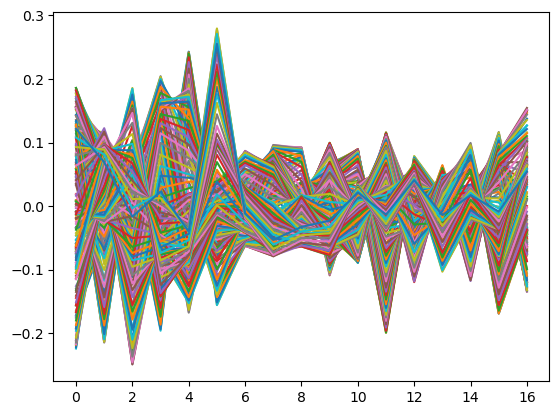

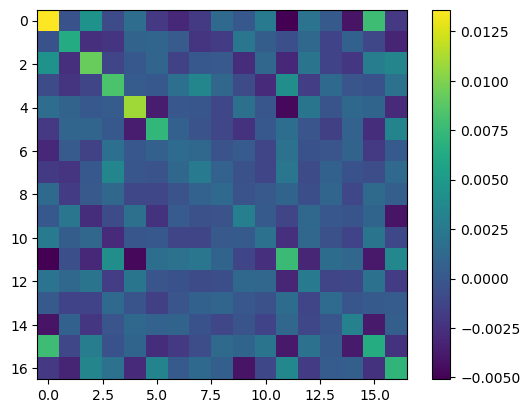

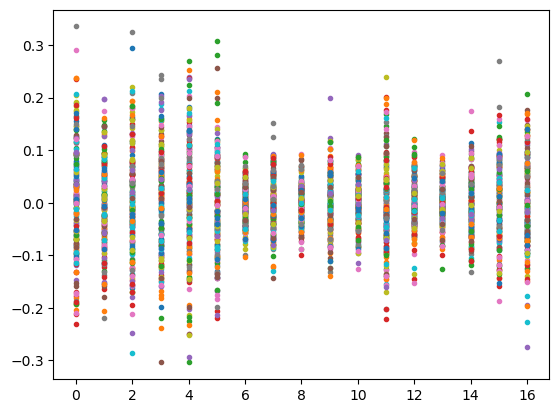

In [38]:
# Whitening
n_samples, dim = x_intern_1.shape

x_center = (x_intern_1 - x_intern_1.mean(0))
plt.plot(x_center.T)

plt.figure()
cov = x_center.T @ x_center / n_samples
plt.imshow(cov)
plt.colorbar()

eval, evec = np.linalg.eigh(cov)
x_center_gauss = np.random.multivariate_normal(np.zeros(dim), cov, size=n_samples)

plt.figure()
_ = plt.plot(x_center_gauss.T, '.')

#ADD PLOTS OF COORDINATES ANALYSIS
#Reconstruction the configuration and compare with original ones